In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.nn import functional as F
import os
import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision.transforms as transforms

from utils.root_path import ultrasound_path
from utils.get_reconstruction_imgs import get_images_for_reconstruction_fetal_abdominal, \
get_images_for_reconstruction_xray_mimic200, get_images_for_reconstruction_crc
from utils.load_real_img import load_real_img_fetalAbdominal, load_real_img_mimic200, load_real_img_crc

In [13]:
results_reconstructions_path = "/local/scratch/clmn1/fednca_journal/reconstructions"

In [ ]:
dataset = "XRayMimic200"

known_label_options = [True, False]
if dataset == "fetalAbdominal":
    images = get_images_for_reconstruction_fetal_abdominal()
    load_real_image = load_real_img_fetalAbdominal
    seg_models = [
        ("unet", "l2_normalized"),
        ("segformer", "l2"),
        ("transunet_b16", "l2"),
        ("new_mednca", "l2_normalized"),
        ("deterministic_mednca", "l2_normalized")
    ]
elif dataset == "XRayMimic200":
    images = get_images_for_reconstruction_xray_mimic200()
    load_real_image = load_real_img_mimic200
    seg_models = [
        ("unet", "l2_normalized"),
        ("segformer", "l2"),
        ("transunet_b16", "l2"),
        ("new_mednca", "l2_normalized"),
        ("deterministic_mednca", "l2_normalized")
    ]
elif dataset == "crc":
    results_reconstructions_path = "/local/scratch/mikonsta/fednca_journal/reconstructions"
    images = get_images_for_reconstruction_crc()
    load_real_image = load_real_img_crc
    seg_models = [
        ("densenet", "l2"),
        ("vit4sgd", "l2"),
        ("maxmednca_nobn", "l2_normalized"),
        ("deterministic_maxmednca_nobn", "l2_normalized")
    ]


In [15]:
def compute_dice(pred, target):
    pred = pred.flatten()
    target = target.flatten()
    intersection = torch.sum(pred * target)
    union = torch.sum(pred) + torch.sum(target)
    if union == 0:
        return 1.0
    return (2.0 * intersection / union).item()

def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target)
    max_val = torch.max(target)
    return (10 * torch.log10(max_val**2 / mse)).item()

def compute_ssim(pred, target):
    pred = pred.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    target = target.unsqueeze(0).unsqueeze(0)
    ssim_value = F.smooth_l1_loss(pred, target, reduction='mean')
    return 1 - ssim_value.item()  # Convert to SSIM scale (1 is perfect similarity)


In [16]:

results = []
skipped_results = 0
for model, distance in tqdm.tqdm(seg_models):
    for known_label in known_label_options:
        for img_name in images:
            d = {
                "case_name": img_name,
                "model": model,
                "known_label": known_label,
            }
            path = os.path.join(results_reconstructions_path, f"{dataset}/{model}/{known_label}_{distance}/{img_name.replace('/', '_')}")
            if not os.path.exists(os.path.join(path, "reconstruction.png")):
                d["psnr"] = None
                d["ssim"] = None
                d["MSE"] = None
                d["dice"] = None
                #results.append(d)
                skipped_results += 1
                print(path)
                continue
            fake_x = Image.open(os.path.join(path, "reconstruction.png"))
            fake_x = transforms.ToTensor()(fake_x)
            if dataset in ["fetalAbdominal", "XRayMimic200"]:
                fake_x = fake_x[0]

            real_x, real_y = load_real_image(img_name)
            d["psnr"] = compute_psnr(fake_x, real_x)
            d["ssim"] = compute_ssim(fake_x, real_x)
            d["MAE"] = F.l1_loss(fake_x, real_x).item()
            d["MSE"] = float(F.mse_loss(fake_x, real_x).item())
            #if not known_label:
            #    fake_y = Image.open(os.path.join(path, "recovered_label.png"))
            #    fake_y = transforms.ToTensor()(fake_y)[0]
            #    d["dice"] = compute_dice(fake_y, real_y)

            results.append(d)

100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


In [17]:
print(f"Done with {len(results)} of {len(results) + skipped_results} results ({100 * len(results) / (len(results) + skipped_results)}%)")

Done with 1000 of 1000 results (100.0%)


In [18]:
results_df = pd.DataFrame(results)
rename_dict = {
    "new_mednca": "FedNCA",
    "deterministic_mednca": "FedNCA\n(deterministic)",
    "unet": "UNet",
    "segformer": "SegFormer",
    "transunet_b16": "TransUNet",
    "vit": "ViT",
    "resnet18": "ResNet18",
    "cnn": "Custom CNN",
    "maxmednca": "FedNCA",
    "deterministic_maxmednca": "FedNCA\n(deterministic)",
    "vit4sgd": "ViT",
    "densenet": "DenseNet",
    "maxmednca_nobn": "FedNCA",
    "deterministic_maxmednca_nobn": "FedNCA\n(deterministic)",
}
results_df["model"] = results_df["model"].apply(lambda x: rename_dict.get(x, x))
results_df

,case_name,model,known_label,psnr,ssim,MAE,MSE
0,3baf6038-bfd20e40-c846d8e3-1595c72a-0a800ef8,UNet,True,24.503267,0.998482,0.038417,0.003037
1,3a8ad427-339e3218-edad034e-d8bba9a1-dbd58800,UNet,True,14.703550,0.983729,0.112880,0.032542
2,3b512d8b-c4775a73-9766b119-c347a598-35c33273,UNet,True,15.943332,0.989193,0.108229,0.021613
3,1b67c53c-d89c7afd-8b0c098e-8619e04e-fc3b95bc,UNet,True,13.184631,0.977284,0.140974,0.045432
4,0ffa6f1c-0a6ec684-9d945729-758f8934-fb485451,UNet,True,12.994285,0.975689,0.153160,0.048623
...,...,...,...,...,...,...,...
995,3adbddf3-4f8e6aa9-e23d6fd0-c84147e6-ee8f2ae3,FedNCA\n(deterministic),False,7.169205,0.922618,0.329782,0.154764
996,02f1f5b4-f5a52a9f-b5c5e1ad-d8e707f9-f303eb9f,FedNCA\n(deterministic),False,7.238619,0.914953,0.338365,0.170094
997,3ae2e517-abb80dae-8c23e59c-857a8bea-7add352f,FedNCA\n(deterministic),False,6.318508,0.918567,0.339872,0.162865
998,0f256000-b7bf1c88-61f4e909-b32ae8a5-eaf80a90,FedNCA\n(deterministic),False,6.606031,0.909580,0.365206,0.180839


In [19]:
known_label_results = results_df[results_df["known_label"] == False]
known_label_results.drop(columns=["case_name", "known_label"], inplace=True)
grouped = known_label_results.groupby("model").mean()
grouped['num_values'] = known_label_results.groupby("model").size()
grouped

/tmp/ipykernel_2406843/2507711554.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  known_label_results.drop(columns=["case_name", "known_label"], inplace=True)


,psnr,ssim,MAE,MSE,num_values
model,,,,,
FedNCA,6.486294,0.913007,0.343769,0.173986,100
FedNCA\n(deterministic),6.529950,0.913794,0.342352,0.172412,100
SegFormer,23.019520,0.997300,0.049049,0.005400,100
TransUNet,8.695745,0.946974,0.256463,0.106051,100
UNet,17.998337,0.990529,0.086531,0.018941,100


In [20]:
grouped = results_df.groupby(["known_label", "model"]).agg(
    # Aggregating all numeric columns
    **{
        f"mean_{col}": (col, "mean")
        for col in results_df.select_dtypes(include="number").columns
    },
    **{
        f"std_{col}": (col, "std")
        for col in results_df.select_dtypes(include="number").columns
    },
    group_size=('model', 'count')  # Add group size
)
grouped

mean_psnr  mean_ssim  mean_MAE  mean_MSE  \
known_label model                                                               
False       FedNCA                    6.486294   0.913007  0.343769  0.173986   
            FedNCA\n(deterministic)   6.529950   0.913794  0.342352  0.172412   
            SegFormer                23.019520   0.997300  0.049049  0.005400   
            TransUNet                 8.695745   0.946974  0.256463  0.106051   
            UNet                     17.998337   0.990529  0.086531  0.018941   
True        FedNCA                    7.145381   0.924276  0.311695  0.151448   
            FedNCA\n(deterministic)   7.002307   0.922453  0.319766  0.155094   
            SegFormer                22.777802   0.997326  0.049988  0.005348   
            TransUNet                 9.767720   0.958117  0.227198  0.083767   
            UNet                     19.183846   0.991598  0.077984  0.016805   

                                     std_psnr  std_ssim   std_MAE   std_MSE  \
known_label model                                                             
False       FedNCA                   1.311364  0.012310  0.024870  0.024621   
            FedNCA\n(deterministic)  1.311784  0.012845  0.025098  0.025691   
            SegFormer                4.438019  0.002938  0.024099  0.005876   
            TransUNet                1.818149  0.011258  0.031668  0.022516   
            UNet                     4.097608  0.008959  0.047803  0.017918   
True        FedNCA                   1.456770  0.015992  0.033681  0.031984   
            FedNCA\n(deterministic)  1.407686  0.012729  0.026440  0.025457   
            SegFormer                3.978309  0.002639  0.021914  0.005279   
            TransUNet                1.931150  0.011152  0.031709  0.022305   
            UNet                     4.627428  0.011101  0.052015  0.022202   

                                     group_size  
known_label model                                
False       FedNCA                          100  
            FedNCA\n(deterministic)         100  
            SegFormer                       100  
            TransUNet                       100  
            UNet                            100  
True        FedNCA                          100  
            FedNCA\n(deterministic)         100  
            SegFormer                       100  
            TransUNet                       100  
            UNet                            100

In [21]:
grouped_for_export = grouped.drop(columns=["group_size"])
for col in ["ssim", "MAE", "MSE"]:
    grouped_for_export[f"mean_{col}"] = grouped_for_export[f"mean_{col}"] * 100
    grouped_for_export[f"std_{col}"] = grouped_for_export[f"std_{col}"] * 100

grouped_for_export = pd.DataFrame({
    "PSNR": grouped_for_export.apply(lambda x: f"{x['mean_psnr']:.2f} ± {x['std_psnr']:.2f}", axis=1),
    "SSIM": grouped_for_export.apply(lambda x: f"{x['mean_ssim']:.2f} ± {x['std_ssim']:.2f}", axis=1),
    "MAE":  grouped_for_export.apply(lambda x: f"{x['mean_MAE']:.2f} ± {x['std_MAE']:.2f}", axis=1),
    "MSE":  grouped_for_export.apply(lambda x: f"{x['mean_MSE']:.2f} ± {x['std_MSE']:.2f}", axis=1),
}, index=grouped_for_export.index)
print(grouped_for_export.to_latex())

\begin{tabular}{llllll}
\toprule
 &  & PSNR & SSIM & MAE & MSE \\
known_label & model &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{False} & FedNCA & 6.49 ± 1.31 & 91.30 ± 1.23 & 34.38 ± 2.49 & 17.40 ± 2.46 \\
 & FedNCA
(deterministic) & 6.53 ± 1.31 & 91.38 ± 1.28 & 34.24 ± 2.51 & 17.24 ± 2.57 \\
 & SegFormer & 23.02 ± 4.44 & 99.73 ± 0.29 & 4.90 ± 2.41 & 0.54 ± 0.59 \\
 & TransUNet & 8.70 ± 1.82 & 94.70 ± 1.13 & 25.65 ± 3.17 & 10.61 ± 2.25 \\
 & UNet & 18.00 ± 4.10 & 99.05 ± 0.90 & 8.65 ± 4.78 & 1.89 ± 1.79 \\
\cline{1-6}
\multirow[t]{5}{*}{True} & FedNCA & 7.15 ± 1.46 & 92.43 ± 1.60 & 31.17 ± 3.37 & 15.14 ± 3.20 \\
 & FedNCA
(deterministic) & 7.00 ± 1.41 & 92.25 ± 1.27 & 31.98 ± 2.64 & 15.51 ± 2.55 \\
 & SegFormer & 22.78 ± 3.98 & 99.73 ± 0.26 & 5.00 ± 2.19 & 0.53 ± 0.53 \\
 & TransUNet & 9.77 ± 1.93 & 95.81 ± 1.12 & 22.72 ± 3.17 & 8.38 ± 2.23 \\
 & UNet & 19.18 ± 4.63 & 99.16 ± 1.11 & 7.80 ± 5.20 & 1.68 ± 2.22 \\
\cline{1-6}
\bottomrule
\end{tabular}



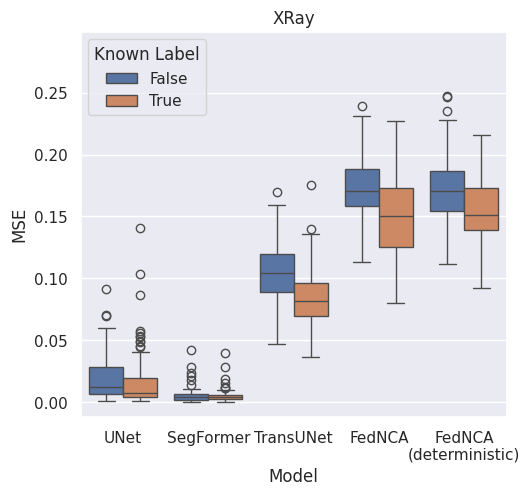

In [ ]:
plt.figure(figsize=(5.5, 5))
sns.set_theme()
sns.boxplot(data=results_df, x="model", y="MSE", hue="known_label")
plt.legend(title="Known Label")
plt.xlabel("Model")
plt.title({"fetalAbdominal": "Ultrasound", "XRayMimic200": "XRay", "crc": "Histopathology"}.get(dataset))
plt.ylim(None, 0.299)
plt.savefig(f"./analysis/reconstruction_{dataset}_mse.pdf", bbox_inches='tight', dpi=300)